# Análise Exploratória de Dados - Adoção de Cães

In [4]:
import pandas as pd

df = pd.read_csv('data/dog_adoption_master.csv')

df_dict = pd.read_csv('data/data_dictionary.csv')


### Análise inicial dos dados

Nesta etapa inicial, vamos verificar o tamanho do dataset, a distribuição dos tipos de variáveis e possíveis problemas de qualidade, como valores ausentes, registros duplicados e candidatos a outliers.

**Resumo encontrado no arquivo `dog_adoption_master.csv`:**
- 42.000 registros e 32 variáveis.
- Predomínio de variáveis numéricas e binárias, além de campos categóricos como raça, porte, tipo de entrada e motivo de devolução.
- Não foram encontrados registros duplicados.
- O único campo com valores ausentes é `days_to_return`, o que é esperado para cães que não foram devolvidos.
- Há candidatos a outliers pelo critério IQR em variáveis contínuas, como `age_years`, `weight_kg`, `days_in_shelter`, `visits_before_adoption` e `days_to_return`; além disso, algumas variáveis codificadas como inteiras/binarizadas também são sinalizadas e devem ser interpretadas com cuidado.

In [5]:
from IPython.display import display

resumo = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'percentual_nulos': (df.isna().mean() * 100).round(2),
})

print(f'Registros: {df.shape[0]:,}'.replace(',', '.'))
print(f'Variáveis: {df.shape[1]}')
print(f'Registros duplicados: {df.duplicated().sum()}')

display(resumo)

colunas_com_nulos = resumo[resumo['nulos'] > 0].sort_values('nulos', ascending=False)
if not colunas_com_nulos.empty:
    display(colunas_com_nulos)

colunas_numericas = df.select_dtypes(include='number').columns
outliers = []
for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    quantidade = int(((df[coluna] < limite_inferior) | (df[coluna] > limite_superior)).sum())
    if quantidade > 0:
        outliers.append({'variavel': coluna, 'outliers_iqr': quantidade})

if outliers:
    display(pd.DataFrame(outliers).sort_values('outliers_iqr', ascending=False))
else:
    print('Nenhum candidato a outlier numérico foi identificado pelo critério IQR.')

Registros: 42.000
Variáveis: 32
Registros duplicados: 0


,tipo,nulos,percentual_nulos
adoption_id,str,0,0.00
age_years,float64,0,0.00
size,str,0,0.00
weight_kg,float64,0,0.00
breed_group,str,0,0.00
intake_type,str,0,0.00
days_in_shelter,int64,0,0.00
previously_returned,int64,0,0.00
medical_needs,str,0,0.00
neutered,int64,0,0.00


,tipo,nulos,percentual_nulos
days_to_return,float64,35703,85.01


,variavel,outliers_iqr
9,met_resident_pets,8024
14,returned,6297
12,size_home_mismatch,4772
3,previously_returned,4723
4,neutered,2999
8,visits_before_adoption,2464
2,days_in_shelter,1422
0,age_years,1222
13,days_to_return,681
11,energy_mismatch,566


### Limpeza dos dados

Nesta etapa, vamos tratar os pontos de qualidade identificados na análise inicial. Como `days_to_return` só existe para cães devolvidos, o valor ausente é estrutural e será tratado de duas formas: remoção nos recortes em que a variável é necessária e preenchimento por zero apenas em uma versão auxiliar para modelagem/consulta.

Também será feita a remoção de duplicados, embora o dataset original não tenha apresentado registros repetidos, e o tratamento de outliers será feito por winsorização com base no critério IQR para preservar o volume de dados.

In [ ]:
from IPython.display import display

df_limpo = df.copy()

quantidade_duplicados = int(df_limpo.duplicated().sum())
df_limpo = df_limpo.drop_duplicates().reset_index(drop=True)

df_limpo['days_to_return_missing'] = df_limpo['days_to_return'].isna().astype(int)
df_limpo['days_to_return_filled'] = df_limpo['days_to_return'].fillna(0)

df_returnidos = df_limpo[df_limpo['days_to_return'].notna()].copy()

colunas_continuas = [
    'age_years',
    'weight_kg',
    'days_in_shelter',
    'aggression_score',
    'anxiety_separation',
    'reactivity_to_dogs',
    'energy_level',
    'training_level',
    'hours_alone_per_day',
    'adopter_activity_level',
    'expectation_score',
    'energy_mismatch',
]

outliers_resumo = []
for coluna in colunas_continuas:
    q1 = df_limpo[coluna].quantile(0.25)
    q3 = df_limpo[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    quantidade_outliers = int(((df_limpo[coluna] < limite_inferior) | (df_limpo[coluna] > limite_superior)).sum())
    if quantidade_outliers > 0:
        outliers_resumo.append({'variavel': coluna, 'outliers_antes': quantidade_outliers})
        df_limpo[coluna] = df_limpo[coluna].clip(limite_inferior, limite_superior)

q1 = df_returnidos['days_to_return'].quantile(0.25)
q3 = df_returnidos['days_to_return'].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers_days_to_return = int(((df_returnidos['days_to_return'] < limite_inferior) | (df_returnidos['days_to_return'] > limite_superior)).sum())
df_returnidos['days_to_return'] = df_returnidos['days_to_return'].clip(limite_inferior, limite_superior)

print(f'Registros originais: {df.shape[0]:,}'.replace(',', '.'))
print(f'Duplicados removidos: {quantidade_duplicados}')
print(f'Registros após remover duplicados: {df_limpo.shape[0]:,}'.replace(',', '.'))
print(f'Valores ausentes em days_to_return: {int(df["days_to_return"].isna().sum())}')
print(f'Strategy 1 - flag criada: days_to_return_missing')
print(f'Strategy 2 - preenchimento auxiliar: days_to_return_filled')
print(f'Registros no subconjunto de devolvidos: {df_returnidos.shape[0]:,}'.replace(',', '.'))
print(f'Outliers em days_to_return antes do corte: {outliers_days_to_return}')

if outliers_resumo:
    display(pd.DataFrame(outliers_resumo).sort_values('outliers_antes', ascending=False))
else:
    print('Nenhum outlier contínuo foi encontrado nas variáveis selecionadas.')

Registros originais: 42.000
Duplicados removidos: 0
Registros após remover duplicados: 42.000
Valores ausentes em days_to_return: 35703
Strategy 1 - flag criada: days_to_return_missing
Strategy 2 - preenchimento auxiliar: days_to_return_filled
Registros no subconjunto de devolvidos: 6.297
Outliers em days_to_return antes do corte: 681


,variavel,outliers_antes
2,days_in_shelter,1422
0,age_years,1222
7,energy_mismatch,566
6,expectation_score,224
5,energy_level,168
4,reactivity_to_dogs,147
3,aggression_score,142
1,weight_kg,104


In [6]:
df.head()

,adoption_id,age_years,size,weight_kg,breed_group,intake_type,days_in_shelter,previously_returned,medical_needs,neutered,...,adopter_activity_level,visits_before_adoption,met_resident_pets,adoption_counseling,expectation_score,energy_mismatch,size_home_mismatch,return_reason,days_to_return,returned
0,ADP000000,2.6,small,7.2,mixed,stray,51,0,none,1,...,2.6,1,0,0,7.3,1.4,0,kept,NaN,0
1,ADP000001,5.4,large,27.9,sporting,stray,38,1,none,1,...,3.8,1,0,0,6.2,4.2,0,kept,NaN,0
2,ADP000002,3.5,medium,15.4,mixed,owner_surrender,14,0,none,1,...,1.1,1,0,0,8.1,3.5,0,kept,NaN,0
3,ADP000003,7.3,medium,23.2,working,stray,9,0,none,1,...,7.8,3,0,1,10.0,0.8,0,unmet_expectations,4.5,1
4,ADP000004,0.7,medium,16.2,mixed,stray,35,1,minor,1,...,3.6,1,0,0,7.9,6.4,0,aggression,12.9,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   adoption_id             42000 non-null  str    
 1   age_years               42000 non-null  float64
 2   size                    42000 non-null  str    
 3   weight_kg               42000 non-null  float64
 4   breed_group             42000 non-null  str    
 5   intake_type             42000 non-null  str    
 6   days_in_shelter         42000 non-null  int64  
 7   previously_returned     42000 non-null  int64  
 8   medical_needs           42000 non-null  str    
 9   neutered                42000 non-null  int64  
 10  aggression_score        42000 non-null  float64
 11  anxiety_separation      42000 non-null  float64
 12  reactivity_to_dogs      42000 non-null  float64
 13  energy_level            42000 non-null  float64
 14  training_level          42000 non-null  float64
 

In [8]:
df.describe()

,age_years,weight_kg,days_in_shelter,previously_returned,neutered,aggression_score,anxiety_separation,reactivity_to_dogs,energy_level,training_level,...,hours_alone_per_day,adopter_activity_level,visits_before_adoption,met_resident_pets,adoption_counseling,expectation_score,energy_mismatch,size_home_mismatch,days_to_return,returned
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,...,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,6297.000000,42000.000000
mean,3.799564,20.269795,35.765524,0.112452,0.928595,2.522829,4.054836,3.499693,6.092600,4.899026,...,5.998119,5.390757,1.734857,0.191048,0.349833,6.613902,2.421643,0.113619,19.357440,0.149929
std,2.667531,12.159154,27.369866,0.315926,0.257503,1.851998,2.168071,2.219308,1.976887,2.302395,...,2.913907,2.151824,0.908114,0.393131,0.476923,1.857971,1.786285,0.317352,39.889637,0.357006
min,0.200000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.800000,8.900000,16.000000,0.000000,1.000000,1.000000,2.500000,1.800000,4.800000,3.300000,...,4.000000,3.900000,1.000000,0.000000,0.000000,5.400000,1.000000,0.000000,2.500000,0.000000
50%,3.200000,18.800000,29.000000,0.000000,1.000000,2.400000,4.000000,3.400000,6.100000,4.900000,...,6.000000,5.400000,1.000000,0.000000,0.000000,6.600000,2.100000,0.000000,6.700000,0.000000
75%,5.200000,28.700000,49.000000,0.000000,1.000000,3.800000,5.500000,5.000000,7.500000,6.500000,...,8.000000,6.900000,2.000000,0.000000,1.000000,7.900000,3.500000,0.000000,18.500000,0.000000
max,16.000000,70.600000,350.000000,1.000000,1.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,14.000000,10.000000,4.000000,1.000000,1.000000,10.000000,10.000000,1.000000,365.000000,1.000000


### Etapa final

Como fechamento, vamos consolidar a base tratada, registrar o tamanho final do conjunto após a limpeza e salvar uma versão pronta para as próximas etapas da análise.

In [ ]:
df_final = df_limpo.copy()

caminho_saida = 'data/dog_adoption_master_limpo.csv'
df_final.to_csv(caminho_saida, index=False)

print(f'Base final tratada: {df_final.shape[0]:,} registros e {df_final.shape[1]} variáveis'.replace(',', '.'))
print(f'Arquivo salvo em: {caminho_saida}')
print(f'Composição final: {df_final["days_to_return"].isna().sum()} valores ausentes em days_to_return preservados como dado estrutural')

Base final tratada: 42.000 registros e 34 variáveis
Arquivo salvo em: data/dog_adoption_master_limpo.csv
Composição final: 35703 valores ausentes em days_to_return preservados como dado estrutural


### Análise estatística

Nesta etapa, vamos calcular medidas descritivas, explorar a distribuição dos dados com gráficos e comparar duas técnicas de amostragem estatística para observar como os resultados podem variar entre amostras.

,média,mediana,moda,desvio padrão,mínimo,máximo
age_years,3.74,3.2,10.3,2.48,0.20,10.30
weight_kg,20.26,18.8,6.6,12.14,2.00,58.40
days_in_shelter,34.95,29.0,98.5,24.63,1.00,98.50
previously_returned,0.11,0.0,0.0,0.32,0.00,1.00
neutered,0.93,1.0,1.0,0.26,0.00,1.00
aggression_score,2.52,2.4,0.0,1.85,0.00,8.00
anxiety_separation,4.05,4.0,0.0,2.17,0.00,10.00
reactivity_to_dogs,3.50,3.4,0.0,2.22,0.00,9.80
energy_level,6.09,6.1,10.0,1.97,0.75,10.00
training_level,4.90,4.9,0.0,2.30,0.00,10.00


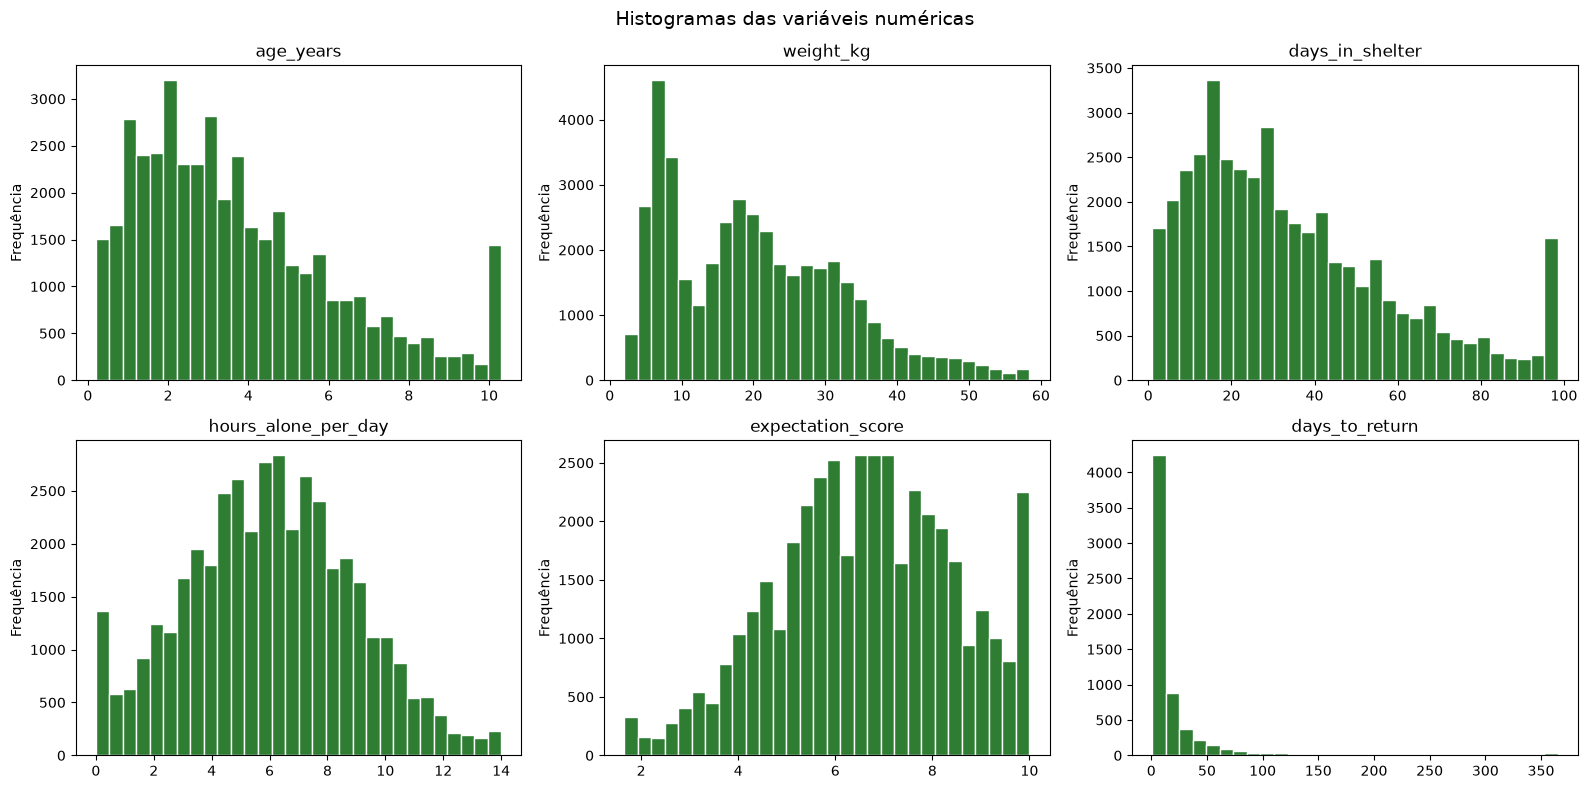

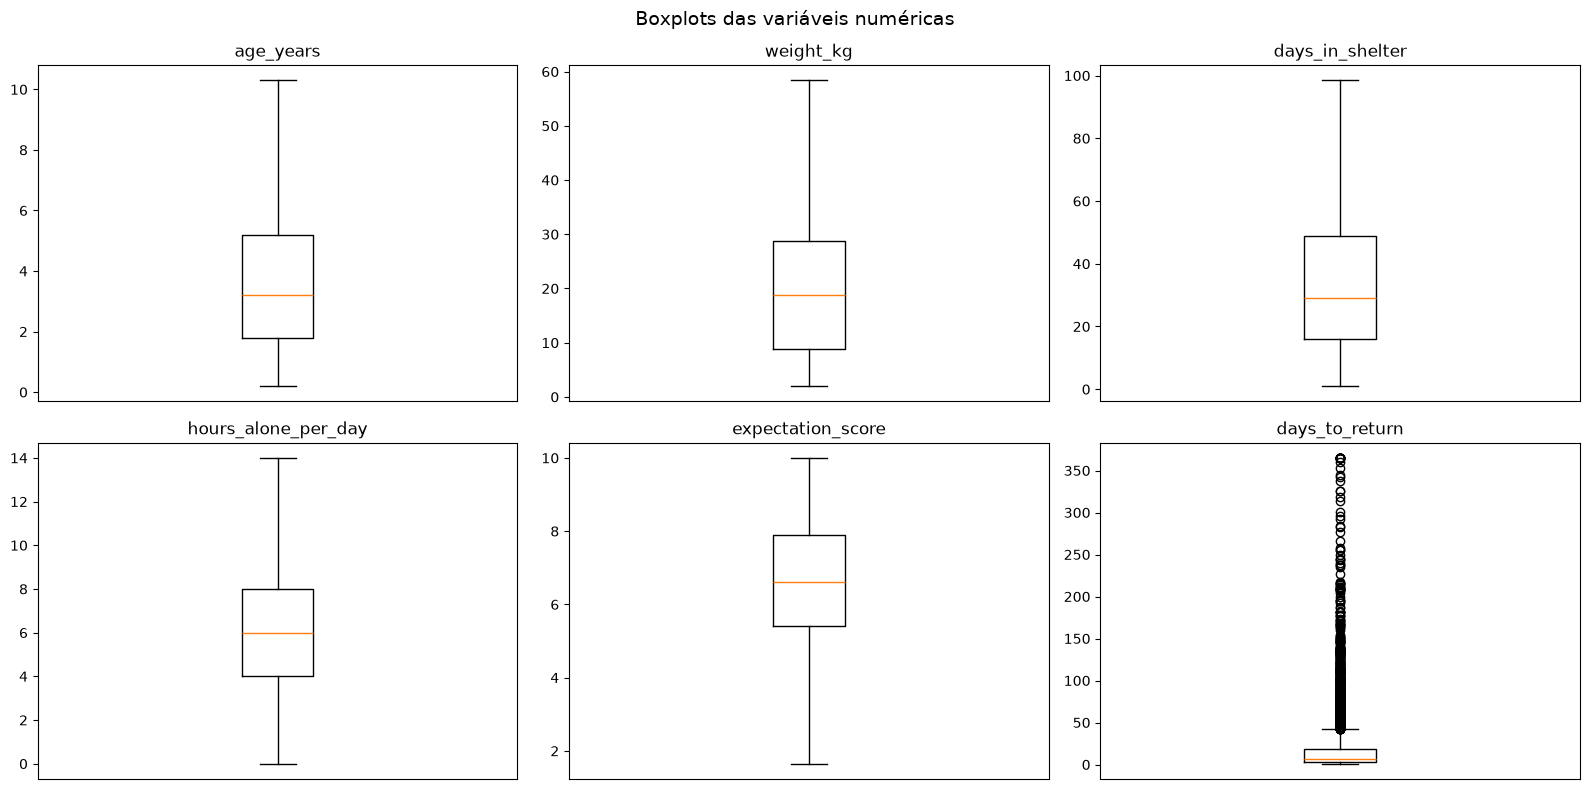

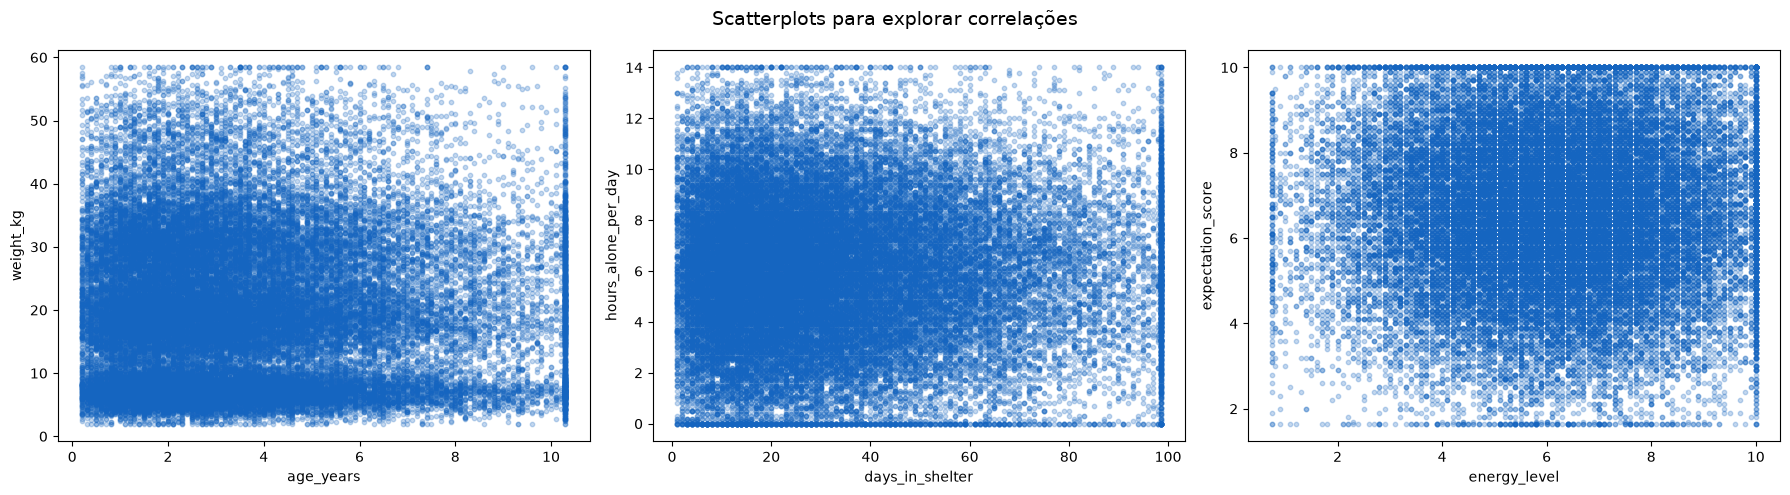

,registros,proporção_retornados,média_idade,média_peso,média_dias_abrigo
população,42000.0,0.150,3.741,20.263,34.952
amostra_aleatória,4200.0,0.154,3.737,20.395,35.018
amostra_estratificada,4200.0,0.150,3.802,20.299,34.026


,proporção_retornados,média_idade,média_peso,média_dias_abrigo
diferença_aleatória,0.004,-0.004,0.132,0.066
diferença_estratificada,0.000,0.061,0.036,-0.926


Diferença observada: a amostra aleatória pode deslocar ligeiramente a proporção de retornados e as médias; a amostra estratificada preserva melhor a composição da população por retornar/manter a proporção das classes.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    base = df_final.copy()
except NameError:
    base = pd.read_csv('data/dog_adoption_master_limpo.csv')
colunas_numericas = [
    coluna for coluna in base.select_dtypes(include='number').columns
    if coluna not in {'days_to_return_missing', 'days_to_return_filled'}
]

medidas = pd.DataFrame(index=colunas_numericas)
medidas['média'] = base[colunas_numericas].mean()
medidas['mediana'] = base[colunas_numericas].median()
medidas['moda'] = [base[coluna].mode(dropna=True).iloc[0] if not base[coluna].mode(dropna=True).empty else pd.NA for coluna in colunas_numericas]
medidas['desvio padrão'] = base[colunas_numericas].std()
medidas['mínimo'] = base[colunas_numericas].min()
medidas['máximo'] = base[colunas_numericas].max()

display(medidas.round(2))

variaveis_histograma = ['age_years', 'weight_kg', 'days_in_shelter', 'hours_alone_per_day', 'expectation_score', 'days_to_return']
fig, eixos = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Histogramas das variáveis numéricas', fontsize=14)
for eixo, coluna in zip(eixos.ravel(), variaveis_histograma):
    dados = base[coluna].dropna() if coluna != 'days_to_return' else base.loc[base['returned'] == 1, coluna].dropna()
    eixo.hist(dados, bins=30, color='#2E7D32', edgecolor='white')
    eixo.set_title(coluna)
    eixo.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

fig, eixos = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Boxplots das variáveis numéricas', fontsize=14)
for eixo, coluna in zip(eixos.ravel(), variaveis_histograma):
    dados = base[coluna].dropna() if coluna != 'days_to_return' else base.loc[base['returned'] == 1, coluna].dropna()
    eixo.boxplot(dados, orientation='vertical')
    eixo.set_title(coluna)
    eixo.set_xticks([])
plt.tight_layout()
plt.show()

fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scatterplots para explorar correlações', fontsize=14)
pares = [
    ('age_years', 'weight_kg'),
    ('days_in_shelter', 'hours_alone_per_day'),
    ('energy_level', 'expectation_score'),
]
for eixo, (x, y) in zip(eixos, pares):
    eixo.scatter(base[x], base[y], alpha=0.25, s=10, color='#1565C0')
    eixo.set_xlabel(x)
    eixo.set_ylabel(y)
plt.tight_layout()
plt.show()

amostra_aleatoria = base.sample(frac=0.10, random_state=42)
amostra_estratificada = base.groupby('returned', group_keys=False).sample(frac=0.10, random_state=42)

def resumo_amostra(df_amostra):
    return pd.Series({
        'registros': len(df_amostra),
        'proporção_retornados': df_amostra['returned'].mean(),
        'média_idade': df_amostra['age_years'].mean(),
        'média_peso': df_amostra['weight_kg'].mean(),
        'média_dias_abrigo': df_amostra['days_in_shelter'].mean(),
    })

comparacao = pd.DataFrame({
    'população': resumo_amostra(base),
    'amostra_aleatória': resumo_amostra(amostra_aleatoria),
    'amostra_estratificada': resumo_amostra(amostra_estratificada),
}).T

display(comparacao.round(3))

diferencas = comparacao.drop(columns=['registros']).loc[['amostra_aleatória', 'amostra_estratificada']].sub(comparacao.drop(columns=['registros']).loc['população'])
diferencas.index = ['diferença_aleatória', 'diferença_estratificada']
display(diferencas.round(3))

print('Diferença observada: a amostra aleatória pode deslocar ligeiramente a proporção de retornados e as médias; a amostra estratificada preserva melhor a composição da população por retornar/manter a proporção das classes.')